In [1]:
import numpy as np
import matplotlib.pyplot as plt

from astropy import units as u

from prism.data import Spectrum
import prism.modeling.models as models
import prism.modeling.fitting as fitting
from prism.modeling.fitting import tie
import prism.modeling.display # importing the display module enables the model display features

plt.rcParams['axes.xmargin'] = 0

In [2]:
filename = 'data/agnspec.txt'

# (Optional) Set the source coordinates and redshift
dec, ra = -25.12345, 13.12345
redshift = 0.0622

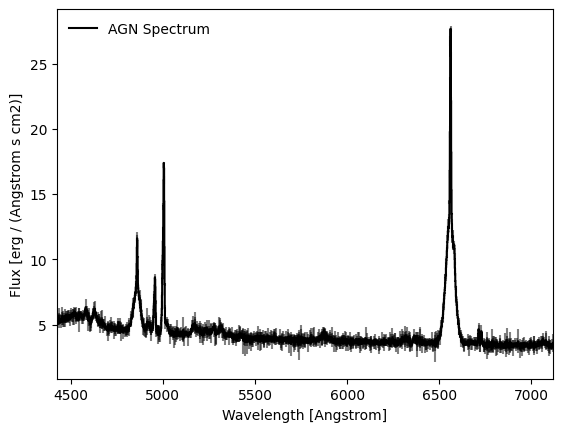

In [3]:
spec = Spectrum.from_txt(filename=filename,
                         ra=ra,
                         dec=dec,
                         z=redshift,
                         wave_unit=u.AA,
                         unit=1e-15 * u.erg / (u.s * u.cm**2 * u.AA),
                         name='AGN Spectrum')

# # (Example) Mask a region
# wmask = (spec.wave <= 5800) | (spec.wave >= 5980)
# spec.crop(wmask=wmask)

# # (Example) Crop a portion of the spectrum
# wbounds = (4800., 7500.) # Å
# spec.crop(wbounds=wbounds)

# Apply Galactic extinction correction
spec.deredden()

# (Optional) Apply redshift correction to rest frame
spec.zcorrect()

spec.err *= 3.0

spec.plot_spectrum() 

In [4]:
# (Optional) Copy locally the CSV file containing the line list, and set up the local line database.
models.setup_local_lines(wmin=np.min(spec.wave), wmax=np.max(spec.wave), overwrite=True)

# # If you want to blindly proceed with the default line list without inspecting it, you can use models.set_wavelength_range()
# # This will just filter the lines to those that fall within the wavelength range of interest.
# models.set_wavelength_range(wmin=np.min(spec.wave), wmax=np.max(spec.wave))

# NOTE: If you decide to work in the observed frame, you should remember to set the line database to the rest frame, i.e. models.set_wavelength_range(wmin=np.min(spec.wave)/(1+redshift), wmax=np.max(spec.wave)/(1+redshift))

Wavelength range set to: [4424.778761061947, 7117.303709282621]


In [5]:
# Line Models support instumental broadening. This can be set to either a constant value (in km/s) or a 2D array with wavelength and FWHM values (in km/s).
# The latter is useful when the instrumental resolution varies significantly across the wavelength range of interest.
# For the sake of simplicity we will use a constant value here, but I leave a snippet below to show how to set up a wavelength-dependent instrumental broadening based on the MUSE instrumental response.

instfwhm = 120. # km/s



# # Set wavelength-dependent instrumental broadening based on the MUSE instrumental response
# from astropy.constants import c
# c_kms = c.to('km/s').value

# # Instrumental Response of MUSE from the MUSE User Manual
# resp_lambda = np.array([4650.0, 5000.0, 5500.0, 6000.0, 6500.0, 7000.0, 7500.0, 8000.0, 8500.0, 9000.0, 9350.0])
# resp_R = np.array([1609, 1750, 1978, 2227, 2484, 2737, 2975, 3183, 3350, 3465, 3506])

# wave_rest = resp_lambda * (1.0 + redshift) # Null the zcorrection for instrumental effects. Not needed if you are working in the observed frame.
# fwhm_km_s = c_kms / resp_R

# instfwhm = np.array([wave_rest, fwhm_km_s]).T

In [6]:
# Setup the model

# Continuum
bknpower = models.BrokenPowerlaw(
    name='bknpower',
    x_ref=5450,
    amplitude=np.median(spec.flux),
    index1=-2.0,
    index2=0.0,
    bounds={
        'x_ref': (5100, 5710),
        'amplitude': (1.5, 5.0),
        'index1': (-3.0, 0.0),
        'index2': (-1.0, 1.5),
    }
)

# Broad Line Region (BLR)
blr = models.agn.blr(
    name='blr',
    amplitude=10,
    offset=-360,
    fwhm=3727,
    instfwhm=instfwhm,
    bounds={
        'amplitude': (0, 1000),
        'offset': (-1000, 1000),
        'fwhm': (500, 8000),
    },
)

# Narrow Line Region (NLR)
nlr = models.agn.nlr(
    name='nlr',
    amplitude=1,
    offset=0,
    fwhm=500,
    instfwhm=instfwhm,
    bounds={
        'amplitude': (0, 100),
        'offset': (-300, 300),
        'fwhm': (0, 800),
    }
)

# Let's add Hydrogen and Helium lines tied to the NLR component. By default they are kept separate.
hhe_nlr = models.GaussianLines.from_csv(
    name='hhe_nlr',
    csv_files=['hydrogen.csv', 'helium.csv'],
    amplitude=1,
    offset=0,
    fwhm=500,
    instfwhm=instfwhm,
    bounds={
        'amplitude': (0, 100),
        'offset': (-300, 300),
        'fwhm': (0, 800),
    }
)
# Link the kinematics of the Hydrogen and Helium lines to those of the NLR component.
hhe_nlr.offset.tied = tie("nlr", lambda m: m.offset)
hhe_nlr.fwhm.tied = tie("nlr", lambda m: m.fwhm)

# OIII outflow
oiii_out = models.GaussianLines.from_csv(
    name='oiii',
    csv_files=['oiii.csv'],
    amplitude=1,
    offset=-560,
    fwhm=850,
    instfwhm=instfwhm,
    bounds={
        'amplitude': (0, 100),
        'offset': (-1000, 750),
        'fwhm': (50, 1500),
    }
)

# FeII Model
fe = models.agn.fe(
    name='fe',
    offset=0,
    fwhm=1200,
    instfwhm=instfwhm,
    bounds={
        'amplitude': (0, 100),
        'offset': (-3000, 3000),
        'fwhm': (800, 3000),
    }
)


# Combine all components
model = bknpower + blr + nlr + hhe_nlr + oiii_out + fe

In [7]:
model

<CompoundModel(bknpower + blr + nlr + hhe_nlr + oiii + fe; amplitude_0=3.92125, x_ref_0=5450, index1_0=-2, index2_0=0, ...)>

In [8]:
# from astropy.modeling.fitting import TRFLSQFitter
# fitter = TRFLSQFitter()

fitter = fitting.SherpaLM() # Very robust altrnative for bounded problems to astropy defaults! Ensure to have Sherpa installed in your environment.

fitted_model = fitter(model=model, x=spec.wave, y=spec.flux, yerr=spec.err, inplace=True)

In [9]:
# Manually print the best-fit parameters
for name in fitted_model.param_names:
    param = getattr(fitted_model, name)
    if hasattr(param, 'std') and param.std is not None:
        print(f"  {name:16s}: {param.value:8.4f} ± {param.std:2g}")
    else:
        print(f"  {name:16s}: {param.value:8.4f}")

  amplitude_0     :   3.9131 ± 0.0041703
  x_ref_0         : 5485.6897 ± 7.90392
  index1_0        :  -1.2526 ± 0.00958081
  index2_0        :   0.6741 ± 0.0102367
  amp_hb4861_1    :   3.1955 ± 0.00581307
  amp_ha6562_1    :   9.2580 ± 0.0310194
  amp_hei4471_1   :   0.2042 ± 0.028993
  amp_heii4685_1  :   0.0020 ± 0.0163803
  amp_hei5877_1   :   0.3694 ± 0.00228831
  amp_hei6678_1   :   0.1438 ± 0.00463061
  amp_hei7065_1   :   0.1958 ± 0.00544579
  offset_1        : -131.4683 ± 1.37017
  fwhm_1          : 2502.0659 ± 2.37244
  redshift_1      :   0.0000
  amp_oiii5007_2  :   7.9427 ± 0.162397
  amp_nii6583_2   :   1.5730 ± 0.0664982
  amp_oi6300_2    :   0.1079 ± 0.0518987
  amp_oi6363_2    :   0.4067 ± 0.0354533
  amp_sii6716_2   :   1.0566 ± 0.0361351
  amp_sii6730_2   :   0.8545 ± 0.00329185
  offset_2        : -58.4548 ± 0.733445
  fwhm_2          : 272.8752 ± 1.7718
  redshift_2      :   0.0000
  amp_hb4861_3    :   4.1546 ± 0.0810833
  amp_ha6562_3    :  14.5623 ± 0.118092
  a

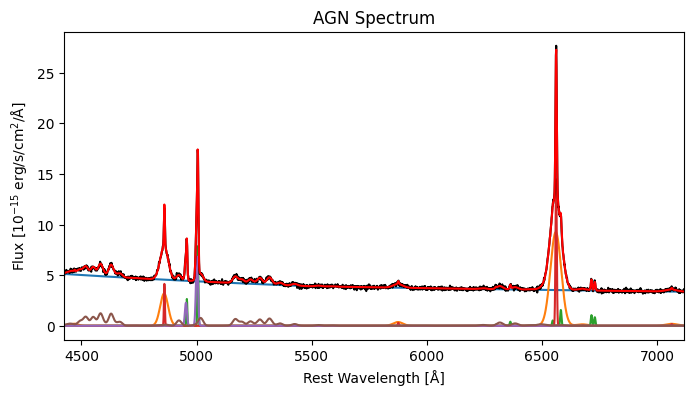

In [10]:
plt.figure(figsize=(8, 4))

comps = models.get_components(fitted_model, additive=True)
for name in comps.names:
    plt.plot(spec.wave, comps[name](spec.wave), label=name)

plt.plot(spec.wave, spec.flux, label='Data', color='black')
plt.plot(spec.wave, fitted_model(spec.wave), label='Model', color='red')
plt.xlabel('Rest Wavelength [Å]')
plt.ylabel('Flux [10$^{-15}$ erg/s/cm$^2$/Å]')

# plt.ylim(bottom=0.1)
# plt.yscale('log')

plt.title(spec.name)

plt.show()

In [11]:
# Our line models support the .flux attribute, which gives us the integrated flux of the line.
nlr.flux

,value,std,lolim,uplim
[OIII]5007,55.977202,1.184337,NaN,NaN
[NII]6583,14.592530,0.621968,NaN,NaN
[OI]6300,0.719361,0.346041,NaN,NaN
[OI]6363,2.738706,0.239221,NaN,NaN
[SII]6716,7.509623,0.260063,NaN,NaN
[SII]6730,6.086445,0.040576,NaN,NaN


In [12]:
# If the fitter uses covariance in the fitting process, by default we will add the .std attribute to the parameters of the model.
# In some cases you might want to estimate the uncertainties on the best-fit parameters using more robust methods, such as bootstrapping.
# We implement it in an easy way in prism, and it can be used with any of the available fitters.
# We perturb the data around their uncertainties, and we refit the model to each perturbed dataset.
# This will give us a distribution of best-fit parameters from which we can estimate the uncertainties.
# We supprt parallelized fitting! For simple models and small datasets, you can set nproc=1 to avoid the overhead of parallelization.
# For more complex models and larger datasets, you can increase nproc to speed up the process.

from prism.modeling.fitting.uncertainty import bootstrap, resample_attach
import astropy.modeling.fitting as astropy_fitting

fitter = astropy_fitting.TRFLSQFitter()
fitter.max_evaluations = 5000

samples = bootstrap(model=fitted_model, 
                    fitter=fitter,
                    x=spec.wave, y=spec.flux, yerr=spec.err,
                    n_samples=200, seed=11,
                    nproc=4,
                    )

Fitting spectra:   0%|          | 0/200 [00:00<?, ?it/s]

In [13]:
# Print the all the best-fit parameters
for name in fitted_model.param_names:
    param = getattr(fitted_model, name)
    if hasattr(param, 'lolim') and param.lolim is not None:
        print(f"  {name:16s}: [{param.lolim:8.4f}, {param.uplim:8.4f}]")
    else:
        print(f"  {name:16s}: {param.value:8.4f}")

  amplitude_0     : [  3.9129,   3.9131]
  x_ref_0         : [5485.6632, 5485.6897]
  index1_0        : [ -1.2526,  -1.2513]
  index2_0        : [  0.6718,   0.6741]
  amp_hb4861_1    : [  3.1955,   3.1970]
  amp_ha6562_1    : [  9.2579,   9.2755]
  amp_hei4471_1   : [  0.2006,   0.2091]
  amp_heii4685_1  : [  0.0020,   0.0150]
  amp_hei5877_1   : [  0.3692,   0.3705]
  amp_hei6678_1   : [  0.1421,   0.1450]
  amp_hei7065_1   : [  0.1958,   0.1995]
  offset_1        : [-131.4807, -131.3726]
  fwhm_1          : [2502.0299, 2502.1756]
  redshift_1      :   0.0000
  amp_oiii5007_2  : [  7.9427,   7.9459]
  amp_nii6583_2   : [  1.5730,   1.5764]
  amp_oi6300_2    : [  0.1079,   0.1112]
  amp_oi6363_2    : [  0.4058,   0.4195]
  amp_sii6716_2   : [  1.0565,   1.0629]
  amp_sii6730_2   : [  0.8541,   0.8565]
  offset_2        : [-58.4561, -58.4463]
  fwhm_2          : [272.8729, 272.8765]
  redshift_2      :   0.0000
  amp_hb4861_3    : [  4.1543,   4.1604]
  amp_ha6562_3    : [ 14.5602,  14

In [14]:
# Print the paramters with fluxes
components = models.get_components(fitted_model)

for i, name in enumerate(components.names):
    comp = components[i]

    if isinstance(comp, models.LineGroupBase):
        for line in comp.lines[comp.lines['weight'] == 1]['name']: # Drop lines with weight!=1. Repeated entries otherwise.
            flux = comp.flux.loc[line, 'value']
            flux_limits = comp.flux.loc[line, ['lolim', 'uplim']]
            if flux_limits.notnull().any():
                print(f"  {name:12s} flux_{line:15s} [{flux_limits['lolim']:8.4f}, {flux_limits['uplim']:8.4f}]")
            else:
                print(f"  {name:12s} flux_{line:15s} {flux:8.4f} ± {comp.flux.loc[line, 'std']:2g}")

    for parname in comp.param_names:
        param = getattr(comp, parname)
        if hasattr(param, 'lolim') and param.lolim is not None:
            print(f"  {name:12s} {parname:20s} [{param.lolim:8.4f}, {param.uplim:8.4f}]")
        else:
            print(f"  {name:12s} {parname:20s} {param.value:8.4f}")


  bknpower     amplitude            [  3.9129,   3.9131]
  bknpower     x_ref                [5485.6632, 5485.6897]
  bknpower     index1               [ -1.2526,  -1.2513]
  bknpower     index2               [  0.6718,   0.6741]
  blr          flux_Hb4861          [138.1020, 138.1756]
  blr          flux_Ha6562          [540.1508, 541.2068]
  blr          flux_HeI4471         [  7.9725,   8.3126]
  blr          flux_HeII4685        [  0.0840,   0.6239]
  blr          flux_HeI5877         [ 19.2923,  19.3582]
  blr          flux_HeI6678         [  8.4340,   8.6114]
  blr          flux_HeI7065         [ 12.2959,  12.5322]
  blr          amp_hb4861           [  3.1955,   3.1970]
  blr          amp_ha6562           [  9.2579,   9.2755]
  blr          amp_hei4471          [  0.2006,   0.2091]
  blr          amp_heii4685         [  0.0020,   0.0150]
  blr          amp_hei5877          [  0.3692,   0.3705]
  blr          amp_hei6678          [  0.1421,   0.1450]
  blr          amp_hei7065   

In [ ]:
from prism.utils import fmt

# Print the all the best-fit parameters
for name in fitted_model.param_names:
    param = getattr(fitted_model, name)
    value = param.median if hasattr(param, 'median') else param.value
    lolim = getattr(param, 'lolim', None)
    uplim = getattr(param, 'uplim', None)
    print(f"  {name:16s}: {fmt(value=value, lo=lolim, hi=uplim)}")


  amplitude_0     : 3.91302 [-0.00013, +0.00007]
  x_ref_0         : 5485.68966 [-0.02649, +0.00001]
  index1_0        : -1.25258 [-0.00007, +0.00131]
  index2_0        : 0.67404 [-0.00220, +0.00006]
  amp_hb4861_1    : 3.1957 [-0.0002, +0.0013]
  amp_ha6562_1    : 9.2583 [-0.0004, +0.0172]
  amp_hei4471_1   : 0.204 [-0.004, +0.005]
  amp_heii4685_1  : 0.002019 [-0.000002, +0.012958]
  amp_hei5877_1   : 0.3695 [-0.0002, +0.0010]
  amp_hei6678_1   : 0.144 [-0.002, +0.001]
  amp_hei7065_1   : 0.1959 [-0.0002, +0.0036]
  offset_1        : -131.47 [-0.01, +0.10]
  fwhm_1          : 2502.07 [-0.04, +0.11]
  redshift_1      : 0
  amp_oiii5007_2  : 7.94273 [-0.00006, +0.00321]
  amp_nii6583_2   : 1.573041 [-0.000002, +0.003368]
  amp_oi6300_2    : 0.1078955 [-0.0000006, +0.0033046]
  amp_oi6363_2    : 0.4067 [-0.0009, +0.0128]
  amp_sii6716_2   : 1.05657 [-0.00004, +0.00630]
  amp_sii6730_2   : 0.8545 [-0.0004, +0.0020]
  offset_2        : -58.455 [-0.001, +0.009]
  fwhm_2          : 272.875 

In [24]:
from prism.utils import tex

for name in fitted_model.param_names:
    param = getattr(fitted_model, name)
    value = param.median if hasattr(param, 'median') else param.value
    lolim = getattr(param, 'lolim', None)
    uplim = getattr(param, 'uplim', None)
    print(f"  {name:16s}: {tex(value=value, lo=lolim, hi=uplim, use_sci=True, maxexp=4)}")

  amplitude_0     : 3.91302_{-0.00013}^{+0.00007}
  x_ref_0         : 5485.689659_{-0.026494}^{+0.000014}
  index1_0        : -1.25258_{-0.00007}^{+0.00131}
  index2_0        : 0.67404_{-0.00220}^{+0.00006}
  amp_hb4861_1    : 3.1957_{-0.0002}^{+0.0013}
  amp_ha6562_1    : 9.2583_{-0.0004}^{+0.0172}
  amp_hei4471_1   : 0.204_{-0.004}^{+0.005}
  amp_heii4685_1  : 0.0020189_{-0.0000019}^{+0.0129582}
  amp_hei5877_1   : 0.3695_{-0.0002}^{+0.0010}
  amp_hei6678_1   : 0.1438_{-0.0018}^{+0.0012}
  amp_hei7065_1   : 0.19595_{-0.00019}^{+0.00356}
  offset_1        : -131.468_{-0.012}^{+0.096}
  fwhm_1          : 2502.07_{-0.04}^{+0.11}
  redshift_1      : 0
  amp_oiii5007_2  : 7.94273_{-0.00006}^{+0.00321}
  amp_nii6583_2   : 1.573041_{-0.000002}^{+0.003368}
  amp_oi6300_2    : 0.1078955_{-0.0000006}^{+0.0033046}
  amp_oi6363_2    : 0.4067_{-0.0009}^{+0.0128}
  amp_sii6716_2   : 1.05657_{-0.00004}^{+0.00630}
  amp_sii6730_2   : 0.8545_{-0.0004}^{+0.0020}
  offset_2        : -58.4548_{-0.0014}^

In [16]:
# Our line models support the .flux attribute, which gives us the integrated flux of the line.
nlr.flux

,value,std,lolim,uplim
[OIII]5007,55.977202,0.482909,55.976383,56.000032
[NII]6583,14.592530,0.146906,14.592405,14.623837
[OI]6300,0.719361,0.143754,0.719352,0.741397
[OI]6363,2.738706,0.113729,2.732890,2.824841
[SII]6716,7.509623,0.084642,7.509299,7.554435
[SII]6730,6.086448,0.022851,6.083306,6.100373


In [17]:
fe.flux

,value,std,lolim,uplim
a4G,7.247562e+01,0.223528,72.362730,72.747917
a4H,1.207633e+00,0.012132,1.206958,1.207854
a6S,5.419326e+01,0.447484,53.946998,54.397839
b2H,1.446584e-04,0.072561,NaN,0.000550
b4D,7.213642e-02,0.196415,0.058417,0.339599
b4F,8.164259e+01,0.364599,81.590059,82.057874
b4P,1.785163e+01,0.013431,17.851328,17.851695
z4D,3.096881e+01,0.549353,30.223145,30.977320
z4F,2.845117e+00,0.287379,2.689047,2.939683
y4G,1.224889e+01,0.344132,12.233740,12.545930


In [18]:
# Access specific entry (pandas.DataFrame)
fe.flux.loc['a4G', 'value']

np.float64(72.47561597294344)

In [19]:
nlr.lines

,name,pos,weight
0,[OIII]5007,4958.896072,0.333333
1,[OIII]5007,5006.803341,1.000000
2,[NII]6583,6548.050000,0.333333
3,[NII]6583,6583.460000,1.000000
4,[OI]6300,6300.304000,1.000000
5,[OI]6363,6363.800000,1.000000
6,[SII]6716,6716.440000,1.000000
7,[SII]6730,6730.810000,1.000000


In [20]:
nlr.eqw() # Compute the Equivalent Width of the line. By default it uses the local continuum, but you can also specify a different continuum model if you want.

# Access the computed EW
nlr.ew

,value,std,lolim,uplim
[OIII]5007,3.220136e+26,2.777973e+24,3.220088e+26,3.221449e+26
[NII]6583,3.526516e+08,3.550226e+06,3.526486e+08,3.534082e+08
[OI]6300,7.417449e+00,1.482274e+00,7.417353e+00,7.644664e+00
[OI]6363,7.492204e+00,3.111266e-01,7.476294e+00,7.727840e+00
[SII]6716,7.907373e+00,8.912472e-02,7.907032e+00,7.954559e+00
[SII]6730,7.924291e+00,2.975049e-02,7.920200e+00,7.942421e+00


In [21]:
fitted_model.show()

In [22]:
# The user can also save the fitted model and its parameters to a file, and load them later for inspection or further analysis, without the need to re-run the fitting process from scratch.
from prism.modeling.io import load_params, load_model

outfile = "results/agnmodel.fits"
fitted_model.save(outfile, overwrite=True)

lp = load_params(outfile)
lm = load_model(outfile)
print("amp_hb:", lp["amp_hb4861_1"])
print("model class:", type(lm).__name__)

amp_hb: 3.195675985317945
model class: CompoundModel
